In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from datetime import datetime, date, time, timedelta

# <span style="color: rgba(27, 230, 0, 0.88);">  **NIVEL 1** </span>
### <span style= "color: rgba(27,230,0, 0.88);"> **N-1.1** </span>
- Conectamos Python con MySQL Workbench y cargamos los datos de tu base de datos de Sprint 4.
- Creamos un df para cada tabla de la base de datos.

In [2]:
import mysql.connector 
# Creamos la conexión
conexion = mysql.connector.connect(
    host= "127.0.0.1",
    user="root",
    password="123456",
    database="tienda_online"
)
# Creamos el cursor para ejecutar consulta SQL  
cursor = conexion.cursor(dictionary=True)
cursor.execute("SHOW TABLES")
# Importamos el resutado
tablas = cursor.fetchall()
# Mostramos las tablas

cursor.execute("SELECT * FROM users")
users = cursor.fetchall()
df_users = pd.DataFrame(users)

cursor.execute("SELECT * FROM transactions")
transactions = cursor.fetchall()
df_transactions = pd.DataFrame(transactions)

cursor.execute("SELECT * FROM companies")
companies = cursor.fetchall()
df_companies = pd.DataFrame(companies)

cursor.execute("SELECT * FROM products ")
products = cursor.fetchall()
df_products = pd.DataFrame(products)

cursor.execute("SELECT * FROM credit_cards ")
credit_cards = cursor.fetchall()
df_credit_cards = pd.DataFrame(credit_cards)

cursor.execute("SELECT * FROM transactions_products")
transactions_products = cursor.fetchall()
df_transactions_products = pd.DataFrame(transactions_products)

cursor.execute("SELECT * FROM estado_de_tarjeta")
estado_de_tarjeta = cursor.fetchall()
df_estado_trajeta = pd.DataFrame(estado_de_tarjeta)

### <span style= "color: rgba(27,230,0, 0.88);"> **N-1.2** </span>

In [3]:
df_transactions_companies = df_transactions.merge(df_companies,left_on="business_id",right_on="company_id",how="left").drop(
                                                                                                       columns="company_id")

##### <span style= "color: rgba(27,230,0, 0.88);"> **UNA VARIABLE NUMERICA** </span> 

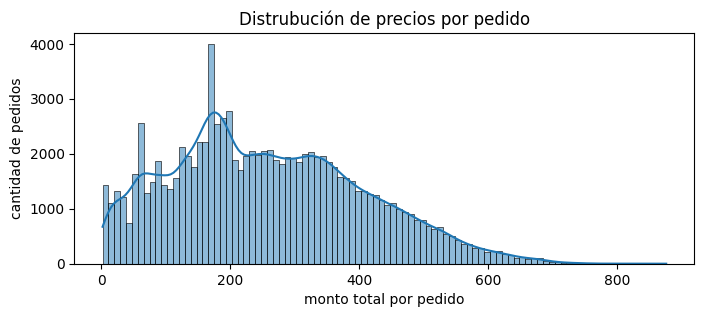

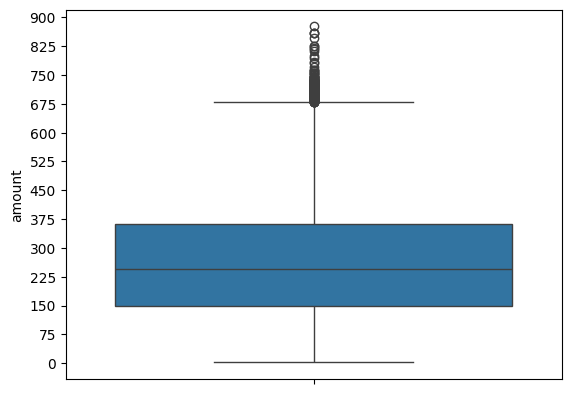

In [4]:
plt.figure(figsize=(8,3))
plt.title("Distrubución de precios por pedido")
sns.histplot(df_transactions["amount"],
            kde=True)
plt.xlabel("monto total por pedido")
plt.ylabel("cantidad de pedidos")
plt.show()

sns.boxplot(df_transactions["amount"])
plt.yticks(range(0, int(df_transactions["amount"].max()) + 75, 75))
plt.show()

##### <span style= "color: rgba(89, 228, 145, 0.88);"> **Podemos observar en los gráficos anteriores que el 50% central de los pedidos se concentra**<br> **aproximadamente entre los 150 y 375 dólares. La mediana ronda los 240 dolares,**<br> **además observamos valores atípicos en pedidos superioes a 675 dólares** </span>

##### <span style= "color: rgba(27,230,0, 0.88);"> **DOS VARIABLES NUMERICA** </span> 

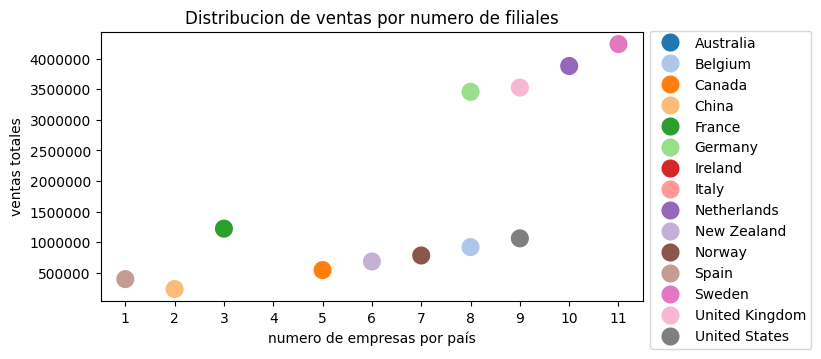

In [5]:

resumen = pd.concat([df_companies.groupby("country")["company_id"].count().rename("num_empresas_pais"),
                     df_transactions_companies[df_transactions_companies["declined"]==0].groupby("country")["amount"].sum(
                     ).round(2).rename("ventas_totales")], axis=1).astype(float)


plt.figure(figsize=(7,3.5))
sns.scatterplot(data=resumen,
               x="num_empresas_pais",
               y="ventas_totales",
               hue="country",
               s=200,
               palette="tab20"
               ).ticklabel_format(style="plain",axis="both")

plt.legend(bbox_to_anchor=(1,1.03), loc="upper left")
plt.xticks(range(1, int(resumen["num_empresas_pais"].max()) + 1, 1))
plt.ylabel("ventas totales")
plt.xlabel("numero de empresas por país")
plt.title("Distribucion de ventas por numero de filiales")
plt.show()

##### <span style= "color: rgba(89, 228, 145, 0.88);"> **El gráfico nos muestra la eficiencia de las empresas por cada país, donde se observa que píses**<br> **como Francia tiene una eficiencia comercial muy destacable en comparacion con otros países como**<br > **Canadá, Nueva zelanda, Noruega y Estados Unidos. Estos ultimos tienen una baja eficiencia comercial** </span>

##### <span style= "color: rgba(27,230,0, 0.88);"> **UNA VARIABLE CATEGÓRICA** </span> 

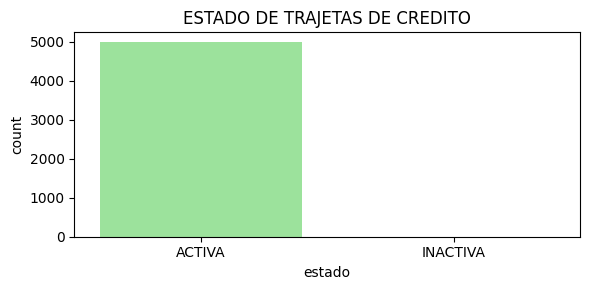

In [6]:
plt.figure(figsize=(6,3))
plt.title("ESTADO DE TRAJETAS DE CREDITO")
sns.barplot(df_estado_trajeta["estado"].value_counts().sort_values(ascending=False),
            color="lightGreen")
plt.tight_layout()
plt.show()

##### <span style= "color: rgba(27,230,0, 0.88);"> **UNA VARIABLE NUMERICA Y UNA CATEGÓRICA** </span> 

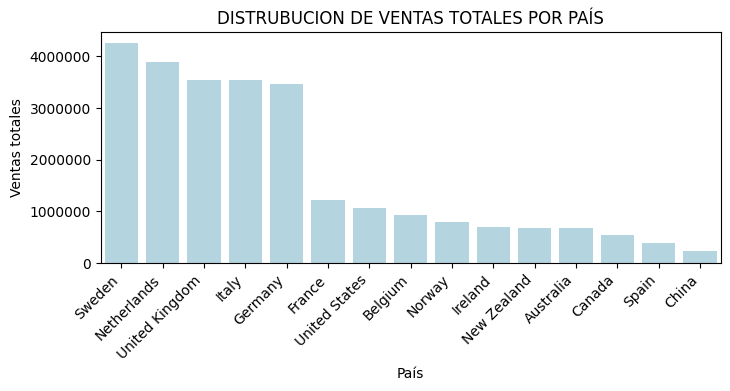

In [7]:
ventas_totales = df_transactions_companies.groupby("country",as_index=False)["amount"].sum().round(2).sort_values(by= "amount",ascending=False)

plt.figure(figsize=(8,3))
plt.title("DISTRUBUCION DE VENTAS TOTALES POR PAÍS")
sns.barplot(data= ventas_totales,
           x= "country",
           y= "amount",
           color="lightBlue"
           ).ticklabel_format(style="plain", axis="y")

plt.xticks(rotation=45, ha="right" )
plt.ylabel("Ventas totales")
plt.xlabel("País")
plt.show()

##### <span style= "color: rgba(89, 228, 145, 0.88);"> **El gráfico nos muestra la eficiencia de las empresas por cada país, donde se observa que píses**<br> **como Francia tiene una eficiencia comercial muy destacable en comparacion con otros países**<br > **como Canadá, Nueva zelanda, Noruega y Estados Unidos.**<br> **Estos ultimos tienen una baja eficiencia comercial** </span>

##### <span style= "color: rgba(27,230,0, 0.88);"> **DOS VARIABLES CATEGÓRICAS** </span> 

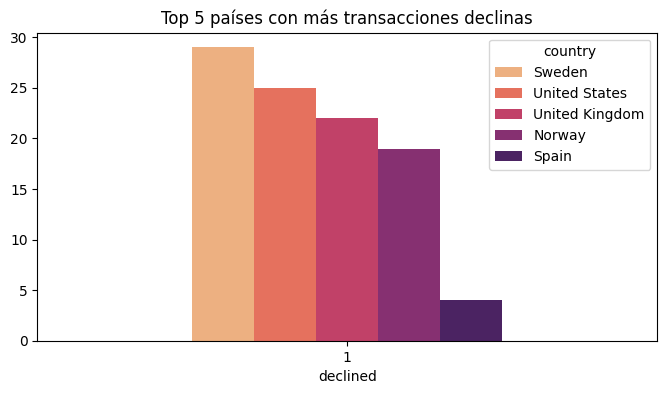

In [8]:
tabla_declinadas_pais = pd.crosstab(df_transactions_companies["country"], df_transactions_companies["declined"]).tail(5)
tabla_declinadas_pais = tabla_declinadas_pais.sort_values(by=1,ascending=False)
tabla_declinadas_pais.drop(columns=0, inplace=True)
tabla_declinadas_pais = tabla_declinadas_pais.T
tabla_declinadas_pais.plot.bar(title= "Top 5 países con más transacciones declinas", 
                               figsize=(8,4), rot=0, cmap="flare")
plt.show()

##### <span style= "color: rgba(27,230,0, 0.88);"> **TREA VARIABLES COMBINADAS** </span> 

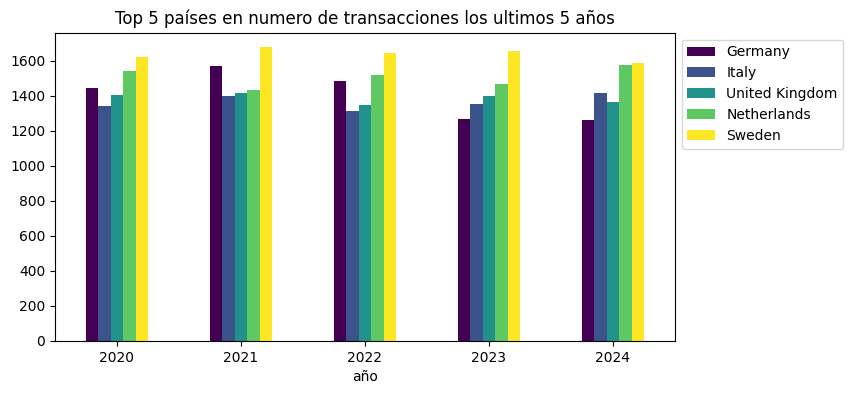

In [9]:
df_transactions_companies["año"] = df_transactions_companies["timestamp"].dt.year
tabla_ventas_año = pd.crosstab(df_transactions_companies["año"], df_transactions_companies["country"], margins=True).tail(6)
tabla_ventas_año = tabla_ventas_año.T.sort_values(by="All")
tabla_ventas_año.drop(index="All", columns="All", inplace=True)
tabla_ventas_año = tabla_ventas_año.tail(5).T

tabla_ventas_año.plot.bar(title="Top 5 países en numero de transacciones los ultimos 5 años",
                                                                            figsize=(8,4), rot= 0,
                                                                            cmap="viridis").legend(bbox_to_anchor=(1.0, 1.0))
plt.show() 
        

##### <span style= "color: rgba(27,230,0, 0.88);"> **CREAMOS UN PAIRPLOT** </span> 

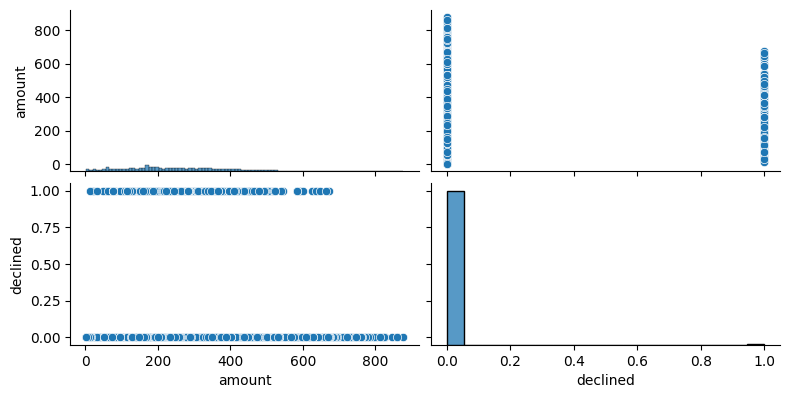

In [10]:
sns.pairplot(data=df_transactions[["amount","declined"]],
             height=2,
             aspect=2)

plt.show()

# <span style="color: rgba(27, 230, 0, 0.88);">  **NIVEL 2** </span>
### <span style= "color: rgba(27,230,0, 0.88);"> **N-2.1** </span>
##### <span style= "color: rgba(89, 228, 145, 0.88);"> **Realizamos una regresion lineal y un heatmap para evaluar si el volumen de ventas aumenta**<br> **a medida que crece el numero de fialiales** </span>

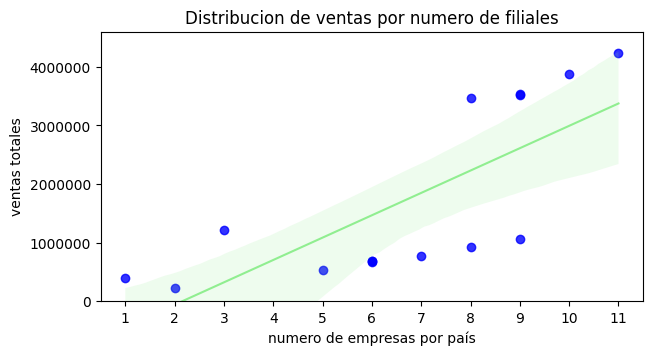

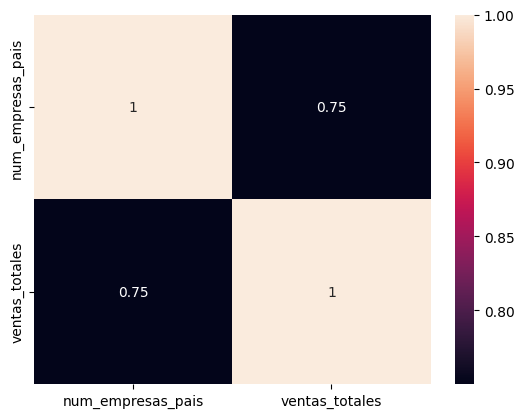

In [11]:
plt.figure(figsize=(7,3.5))
sns.regplot(
    data=resumen,
    x="num_empresas_pais",
    y="ventas_totales",
    scatter=True,
    color="blue",
    line_kws={"color": "lightGreen", "linewidth": 1.5}
)

plt.ticklabel_format(style="plain", axis="both")
plt.ylim(bottom=0)
plt.xticks(range(1, int(resumen["num_empresas_pais"].max()) + 1, 1))
plt.ylabel("ventas totales")
plt.xlabel("numero de empresas por país")
plt.title("Distribucion de ventas por numero de filiales")
plt.show() 

tabla_resumen = resumen[["num_empresas_pais","ventas_totales"]].corr()
sns.heatmap(data=tabla_resumen,
            annot=True,
            cmap="rocket")
plt.show()

##### <span style= "color: rgba(89, 228, 145, 0.88);"> **Podemos observar una correlación positiva entre, el volumen de ventas y el numero de filiales, dado que el coeficiente**<br> **de correlación es de 0,75, lo que indica una relación lineal considerable entre ambas variables.** </span>

### <span style= "color: rgba(27,230,0, 0.88);"> **N-2.2** </span>
##### <span style= "color: rgba(89, 228, 145, 0.88);"> **Realizamos JOINPLOT** </span>

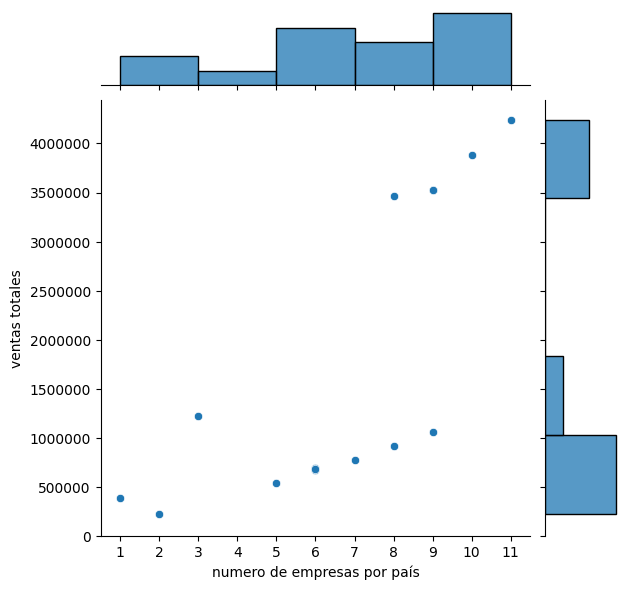

In [12]:
sns.jointplot(data=resumen,
              x="num_empresas_pais",
              y="ventas_totales",
              kind="scatter")
plt.ticklabel_format(style="plain", axis="both")
plt.ylim(bottom=0)
plt.xticks(range(1, int(resumen["num_empresas_pais"].max()) + 1, 1))
plt.ylabel("ventas totales")
plt.xlabel("numero de empresas por país")
plt.show()

##### <span style= "color: rgba(89, 228, 145, 0.88);"> **El jointplot muestra una relación positiva entre el número de filiales y el volumen de ventas totales.**<br> **En general, los países con mayor número de filiales tienden a registrar mayores ventas, aunque existen**<br> **algunas diferencias entre países que indican que la relación no es completamente uniforme.** </span>